## 6.10 Bayesian linear regression

Before turning samplers loose on intractable problems, it pays to work through a model we **can** solve exactly — and then verify the samplers against it.

**Model.** We fit a straight line $y_i = w_0 + w_1 x_i + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma_n^2)$.  In matrix form with design matrix $\boldsymbol{\Phi}$ ($\Phi_{ij} = \phi_j(x_i)$, $\boldsymbol{\phi}(x)=(1,x)^\top$):

$$p(\boldsymbol{y}\mid\boldsymbol{w}) = \mathcal{N}(\boldsymbol{y};\,\boldsymbol{\Phi w}, \mathbf{C}_N).$$

**Gaussian prior** on the weights: $p(\boldsymbol{w}) = \mathcal{N}(\boldsymbol{w};\mathbf{m}_0,\mathbf{S}_0)$.

**Exact posterior** (Eq.\ 6.51 — precisions add, means are precision-weighted):

$$p(\boldsymbol{w}\mid\boldsymbol{y}) = \mathcal{N}(\boldsymbol{w};\mathbf{m}_N,\mathbf{S}_N),$$

$$\mathbf{S}_N^{-1} = \mathbf{S}_0^{-1} + \boldsymbol{\Phi}^\top\mathbf{C}_N^{-1}\boldsymbol{\Phi},\qquad \mathbf{m}_N = \mathbf{S}_N\!\left(\mathbf{S}_0^{-1}\mathbf{m}_0 + \boldsymbol{\Phi}^\top\mathbf{C}_N^{-1}\boldsymbol{y}\right).$$

With $\mathbf{m}_0=\mathbf{0}$, $\mathbf{S}_0=\tau^2\mathbf{I}$, $\mathbf{C}_N=\sigma_n^2\mathbf{I}$ this reduces to **ridge regression**: $\mathbf{m}_N = (\boldsymbol{\Phi}^\top\boldsymbol{\Phi}+\lambda\mathbf{I})^{-1}\boldsymbol{\Phi}^\top\boldsymbol{y}$, $\lambda=\sigma_n^2/\tau^2$.

**Two ways to sample the posterior** (both must agree with the exact result):
1. **Cholesky** — draw exact independent samples: $\boldsymbol{w} = \mathbf{m}_N + \mathbf{L}\mathbf{z}$, $\mathbf{L}\mathbf{L}^\top=\mathbf{S}_N$, $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$.
2. **Metropolis-Hastings** — random-walk MCMC on $\log p(\boldsymbol{w}\mid\boldsymbol{y})$ with proposal $\boldsymbol{\Sigma}_{\rm prop}=\frac{2.38^2}{d}\mathbf{S}_N$ (optimal scaling for a $d$-dimensional Gaussian; Eq.\ 6.53).  Any discrepancy from the exact answer is a bug in the sampler, not a feature of the model.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.stats import multivariate_normal as mvn_dist, norm as norm_dist

# ── Plotting style (shared across all section-6 lecture plots) ─────────────
fontsi  = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi2,
    'axes.titlesize':    fontsi2,
    'axes.labelsize':    fontsi2,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})

# ---------------------------------------------------------------------------
# Data: N straight-line observations with Gaussian noise
# Design matrix Phi: rows are phi(x_i) = (1, x_i)  — intercept and slope
# ---------------------------------------------------------------------------
_rng_lr = np.random.default_rng(seed=42)

W_TRUE  = np.array([2.5, 1.8])   # true intercept w0 and slope w1
SIGMA_N = 0.5                      # noise std (assumed known)
TAU     = 3.0                      # prior std — broad, weakly informative
N_DATA  = 30

x_data = np.linspace(-2, 2, N_DATA)
y_data = W_TRUE[0] + W_TRUE[1]*x_data + _rng_lr.normal(0, SIGMA_N, N_DATA)

# Design matrix and noise precision (diagonal because errors are independent)
Phi     = np.column_stack([np.ones(N_DATA), x_data])   # (N, 2)
C_N_inv = np.eye(N_DATA) / SIGMA_N**2

# ---------------------------------------------------------------------------
# Exact posterior  p(w|y) = N(w; m_N, S_N)  via Eq. 6.51
#
# Key insight: precisions (inverse covariances) add.
#   S_N^{-1} = S_0^{-1}  +  Phi^T C_N^{-1} Phi
#              (prior)        (data information)
#
# As N -> inf the data term dominates and the posterior forgets the prior.
# ---------------------------------------------------------------------------
m0      = np.zeros(2)
S0_inv  = np.eye(2) / TAU**2

S_N_inv = S0_inv + Phi.T @ C_N_inv @ Phi   # posterior precision
S_N     = np.linalg.inv(S_N_inv)            # posterior covariance
m_N     = S_N @ (S0_inv @ m0 + Phi.T @ C_N_inv @ y_data)



Gaussian (Cholesky) samples:
  w0: 2.5051 +/- 0.0918   (exact: 2.5061 +/- 0.0912)
  w1: 1.8606 +/- 0.0767   (exact: 1.8590 +/- 0.0764)

MH sampler:
  acceptance rate = 0.484   (optimal ~0.234 for d=2)
  4000 burn-in steps discarded,  36,000 post-burn-in samples
  w0: 2.5037 +/- 0.0909   (exact: 2.5061 +/- 0.0912)
  w1: 1.8577 +/- 0.0763   (exact: 1.8590 +/- 0.0764)


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_65408/4230170314.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


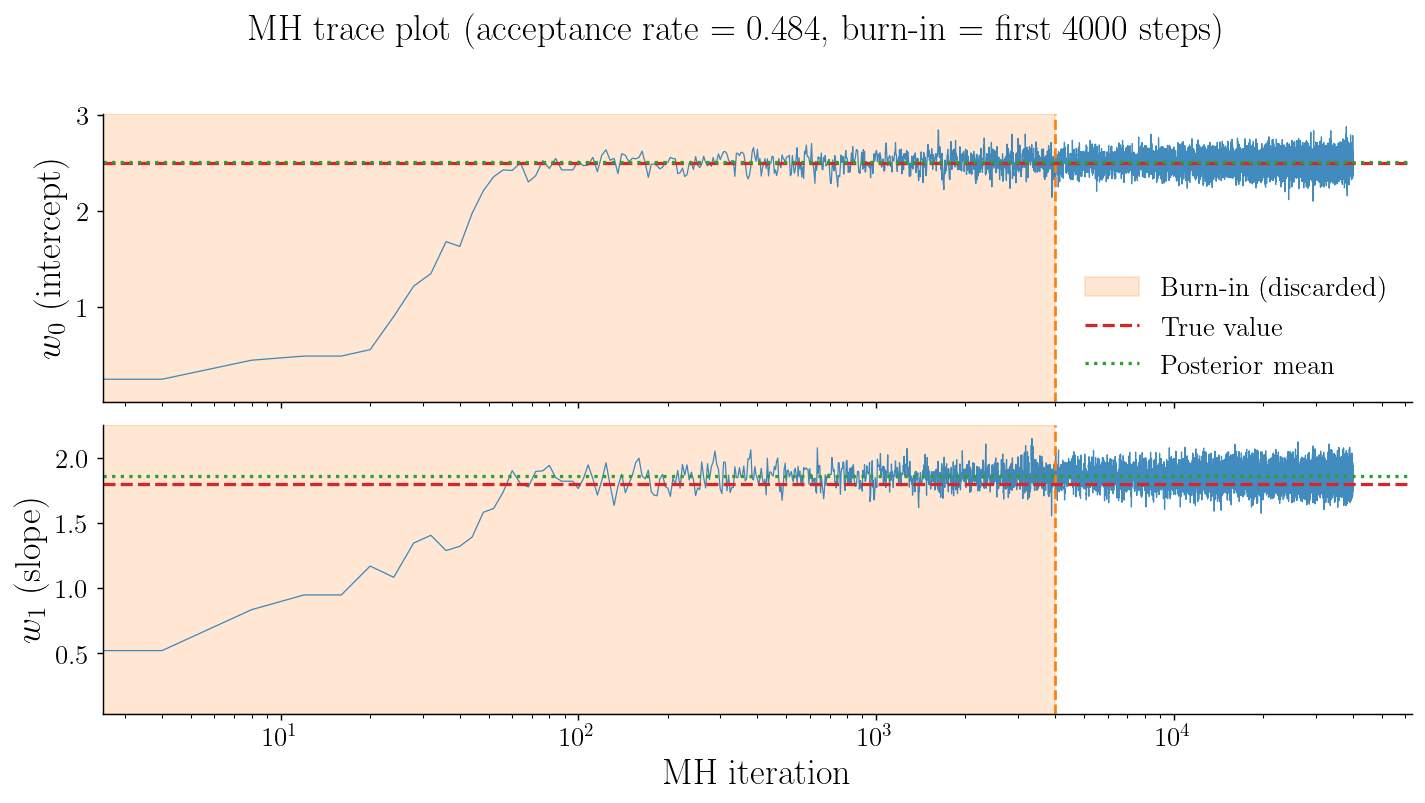

In [52]:
# ---------------------------------------------------------------------------
# Method 1: Direct Gaussian sampling via Cholesky factorisation
#
# p(w|y) = N(m_N, S_N), so we can draw exact, independent samples:
#   w = m_N + L @ z,   where  L L^T = S_N  and  z ~ N(0, I)
#
# This is always the first choice when the posterior is Gaussian —
# every sample is independent (N_eff = N_samples, zero autocorrelation).
# We use these samples as the ground truth to validate the MH chain.
# ---------------------------------------------------------------------------
N_GAUSS = 10_000
L_chol  = np.linalg.cholesky(S_N)           # S_N = L L^T
w_gauss = m_N + (L_chol @ _rng_lr.normal(0, 1, (2, N_GAUSS))).T

print('Gaussian (Cholesky) samples:')
print(f'  w0: {w_gauss[:,0].mean():.4f} +/- {w_gauss[:,0].std():.4f}'
      f'   (exact: {m_N[0]:.4f} +/- {np.sqrt(S_N[0,0]):.4f})')
print(f'  w1: {w_gauss[:,1].mean():.4f} +/- {w_gauss[:,1].std():.4f}'
      f'   (exact: {m_N[1]:.4f} +/- {np.sqrt(S_N[1,1]):.4f})')

# ---------------------------------------------------------------------------
# Method 2: Metropolis-Hastings
#
# We hand the sampler only the log-posterior — it does NOT know the
# posterior is Gaussian.  After burn-in it must converge to the same
# distribution as the Cholesky samples.
#
# Log-posterior (unnormalised):
#   log p(w|y) = log p(y|w) + log p(w)
#              = -1/(2 sigma_n^2) ||y - Phi w||^2  -  1/(2 tau^2) ||w||^2
# ---------------------------------------------------------------------------

def log_posterior_lr(w):
    '''Log-posterior: log-likelihood + log-prior (unnormalised).'''
    residual  = y_data - Phi @ w
    log_lik   = -0.5 * np.dot(residual, residual) / SIGMA_N**2
    log_prior = -0.5 * w @ S0_inv @ w
    return log_lik + log_prior

def run_mh(log_post_fn, w_start, n_steps, prop_cov, rng):
    '''Random-walk Metropolis-Hastings with a Gaussian proposal.

    The proposal w' = w + eps with eps ~ N(0, prop_cov) is symmetric,
    so the q(w|w')/q(w'|w) ratio in the acceptance probability cancels.
    Returns (chain of shape (n_steps, d), acceptance rate).
    '''
    d, n_acc  = len(w_start), 0
    chain     = np.zeros((n_steps, d))
    w_cur     = w_start.copy()
    lp_cur    = log_post_fn(w_cur)
    L_prop    = np.linalg.cholesky(prop_cov)   # pre-factor for fast draws

    for i in range(n_steps):
        #w_prop  = w_cur + L_prop @ rng.normal(0, 1, d)
        w_prop  = w_cur + 0.1* rng.normal(0, 1, d)
        lp_prop = log_post_fn(w_prop)

        # Accept if log(u) < log alpha = log p(w') - log p(w)
        if np.log(rng.uniform()) < lp_prop - lp_cur:
            w_cur, lp_cur = w_prop, lp_prop
            n_acc += 1

        chain[i] = w_cur

    return chain, n_acc / n_steps

# Optimal proposal: Sigma_prop = (2.38^2 / d) * S_N  (Roberts et al. 1997)
# For a Gaussian target this gives acceptance rate ~ 23.4% in d=2
D_PARAM    = 2
N_STEPS    = 40_000
BURN_IN    = 4_000    # first ~10% discarded while chain moves from prior to posterior
Sigma_prop = (2.38**2 / D_PARAM) * S_N

# Start at the prior mean (origin) — far from the posterior ~ (2.5, 1.8)
# so the burn-in transition is clearly visible in the trace plot
chain_all, acc_rate = run_mh(log_posterior_lr,
                              w_start=np.zeros(2),
                              n_steps=N_STEPS,
                              prop_cov=Sigma_prop,
                              rng=_rng_lr)
w_mh = chain_all[BURN_IN:]

print(f'\nMH sampler:')
print(f'  acceptance rate = {acc_rate:.3f}   (optimal ~0.234 for d=2)')
print(f'  {BURN_IN} burn-in steps discarded,  {len(w_mh):,} post-burn-in samples')
print(f'  w0: {w_mh[:,0].mean():.4f} +/- {w_mh[:,0].std():.4f}'
      f'   (exact: {m_N[0]:.4f} +/- {np.sqrt(S_N[0,0]):.4f})')
print(f'  w1: {w_mh[:,1].mean():.4f} +/- {w_mh[:,1].std():.4f}'
      f'   (exact: {m_N[1]:.4f} +/- {np.sqrt(S_N[1,1]):.4f})')

# ---------------------------------------------------------------------------
# Trace plot: burn-in transient + stationary mixing
# After burn-in the chain should fluctuate stably around the posterior mean.
# The orange shading marks the burn-in region we discard.
# ---------------------------------------------------------------------------
SHOW = 40_000
THIN = 4

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                          gridspec_kw={'hspace': 0.08})

for ax, idx, label, true_val in [
    (axes[0], 0, r'$w_0$ (intercept)', W_TRUE[0]),
    (axes[1], 1, r'$w_1$ (slope)',     W_TRUE[1]),
]:
    iters = np.arange(SHOW // THIN) * THIN
    ax.semilogx(iters, chain_all[:SHOW:THIN, idx], color='tab:blue', lw=0.7, alpha=0.85)
    ax.axvspan(0, BURN_IN, color='tab:orange', alpha=0.18, label='Burn-in (discarded)')
    ax.axvline(BURN_IN, color='tab:orange', lw=1.5, ls='--')
    ax.axhline(true_val, color='tab:red',   lw=1.8, ls='--', label='True value')
    ax.axhline(m_N[idx], color='tab:green', lw=1.8, ls=':',  label='Posterior mean')
    ax.set_ylabel(label, fontsize=fontsi2)
    if idx == 0:
        ax.legend(fontsize=fontsi, loc='lower right')
    ax.tick_params(labelsize=fontsi)

axes[1].set_xlabel('MH iteration', fontsize=fontsi2)
plt.suptitle(f'MH trace plot  (acceptance rate = {acc_rate:.3f},  '
             f'burn-in = first {BURN_IN} steps)',
             y=1.01, fontsize=fontsi2)
plt.tight_layout()
plt.savefig('6_linreg_trace.pdf', bbox_inches='tight')
plt.show()


Gelman-Rubin R-hat  (< 1.01 = converged):
  w0: 1.00011
  w1: 1.00002

Integrated autocorrelation time:
  w0: tau = 9.6,   N_eff = 3736 / 36,000
  w1: tau = 7.3,   N_eff = 4953 / 36,000


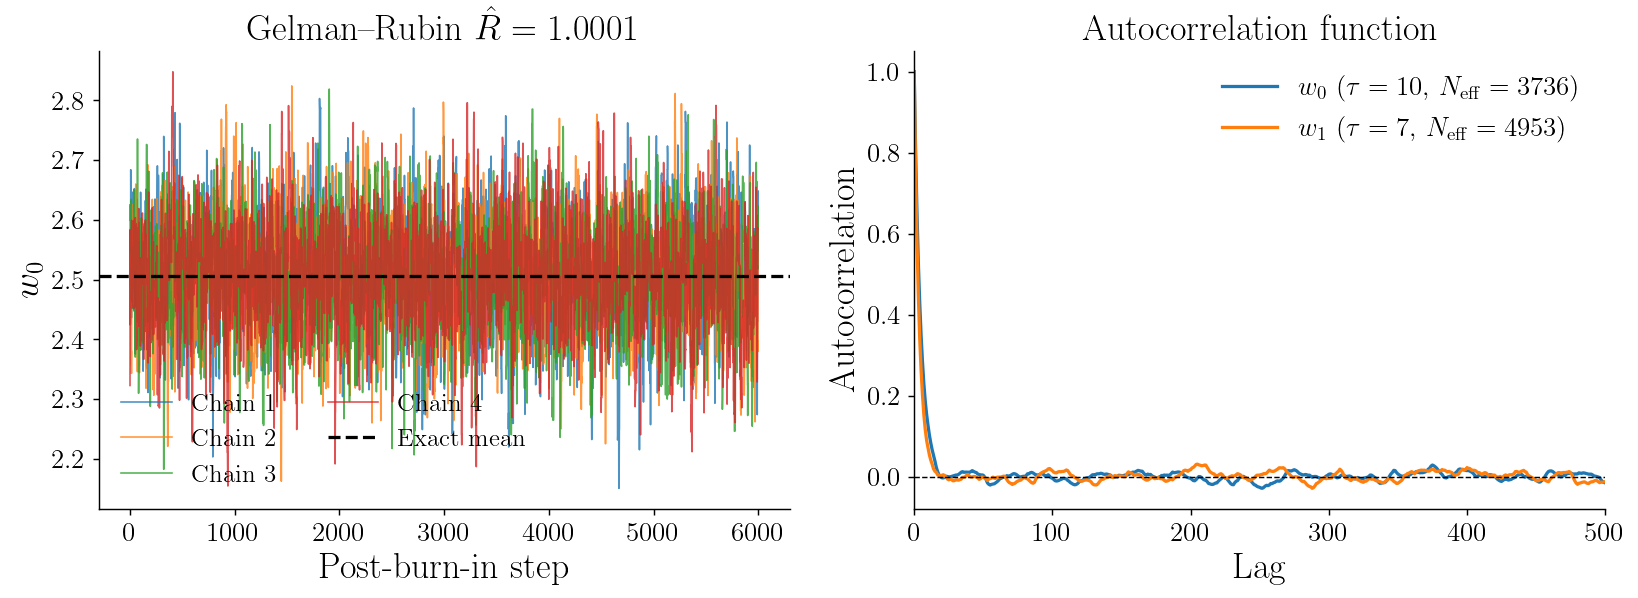

In [53]:
from scipy.stats import chi2

# ---------------------------------------------------------------------------
# 1. Gelman–Rubin R-hat
#
# Run 4 chains from dispersed starting points (far from the posterior).
# R-hat compares within-chain variance W to between-chain variance B:
#
#   V = (N-1)/N * W  +  B/N       (pooled variance estimate)
#   R-hat = sqrt(V / W)
#
# R-hat -> 1 from above as the chains forget their initial conditions.
# Values < 1.01 are universally accepted as convergence.
# ---------------------------------------------------------------------------
N_CHAINS = 4
starts = [np.zeros(2),
          np.array([ 5.0,  5.0]),
          np.array([-5.0,  5.0]),
          np.array([ 0.0, -5.0])]

chains_multi = []
for w0 in starts:
    ch, _ = run_mh(log_posterior_lr, w0, N_STEPS, Sigma_prop, _rng_lr)
    chains_multi.append(ch[BURN_IN:])   # discard burn-in for every chain

def gelman_rubin(chains):
    '''R-hat per parameter (Gelman & Rubin 1992).'''
    M   = len(chains)
    N   = min(len(c) for c in chains)
    arr = np.stack([c[:N] for c in chains])   # (M, N, d)
    psi_m = arr.mean(axis=1)                  # (M, d) chain means
    psi   = psi_m.mean(axis=0)               # (d,)   grand mean
    B     = N / (M - 1) * ((psi_m - psi)**2).sum(axis=0)
    W     = np.var(arr, axis=1, ddof=1).mean(axis=0)
    V     = (N - 1) / N * W + B / N
    return np.sqrt(V / W)

R_hat = gelman_rubin(chains_multi)
print('Gelman-Rubin R-hat  (< 1.01 = converged):')
print(f'  w0: {R_hat[0]:.5f}')
print(f'  w1: {R_hat[1]:.5f}')

# ---------------------------------------------------------------------------
# 2. Integrated autocorrelation time (IAT)
#
# Consecutive MH samples are correlated.  The IAT measures how many
# steps produce one effectively independent sample:
#
#   tau = 1 + 2 sum_{k=1}^inf rho(k)
#
# N_eff = N / tau  is the number of independent samples in the chain.
# We use Sokal's automatic window to truncate the sum before noise
# dominates the tail of the ACF.
# ---------------------------------------------------------------------------
def acf_fft(x, max_lag):
    '''Normalised autocorrelation via FFT zero-padding (fast for large N).'''
    n  = len(x)
    xc = x - x.mean()
    f  = np.fft.rfft(xc, n=2 * n)
    ac = np.fft.irfft(f * np.conj(f))[:n].real
    return ac[:max_lag + 1] / ac[0]

def iat_sokal(rho, c=5):
    '''IAT with Sokal automatic window: stop when window k >= c * tau.'''
    tau = 1.0
    for k in range(1, len(rho)):
        tau += 2 * rho[k]
        if k >= c * tau:
            break
    return max(tau, 1.0)

MAX_LAG = 500
lags    = np.arange(MAX_LAG + 1)
acf_0   = acf_fft(w_mh[:, 0], MAX_LAG)
acf_1   = acf_fft(w_mh[:, 1], MAX_LAG)
tau_0   = iat_sokal(acf_0)
tau_1   = iat_sokal(acf_1)
Neff_0  = len(w_mh) / tau_0
Neff_1  = len(w_mh) / tau_1

print(f'\nIntegrated autocorrelation time:')
print(f'  w0: tau = {tau_0:.1f},   N_eff = {Neff_0:.0f} / {len(w_mh):,}')
print(f'  w1: tau = {tau_1:.1f},   N_eff = {Neff_1:.0f} / {len(w_mh):,}')

# ---------------------------------------------------------------------------
# Figure: two-panel convergence summary
# ---------------------------------------------------------------------------
SHOW_GR = 6_000
cmap_gr = [plt.cm.tab10(v) for v in [0.0, 0.1, 0.2, 0.3]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: multi-chain trace (w0) with R-hat annotation ──────────────────────
ax = axes[0]
for j, ch in enumerate(chains_multi):
    n_show = min(SHOW_GR, len(ch))
    ax.plot(np.arange(n_show), ch[:n_show, 0],
            lw=0.9, alpha=0.8, color=cmap_gr[j], label=f'Chain {j+1}')
ax.axhline(m_N[0], color='k', lw=1.8, ls='--', label='Exact mean')
ax.set_xlabel('Post-burn-in step', fontsize=fontsi2)
ax.set_ylabel(r'$w_0$', fontsize=fontsi2)
ax.set_title(rf'Gelman--Rubin  $\hat{{R}}={R_hat[0]:.4f}$', fontsize=fontsi2)
ax.legend(fontsize=fontsi - 1, ncol=2)
ax.tick_params(labelsize=fontsi)

# ── Right: ACF for both parameters ──────────────────────────────────────────
ax = axes[1]
ax.plot(lags, acf_0, color='tab:blue',   lw=1.8,
        label=rf'$w_0$  ($\tau={tau_0:.0f}$,  $N_{{\rm eff}}={Neff_0:.0f}$)')
ax.plot(lags, acf_1, color='tab:orange', lw=1.8,
        label=rf'$w_1$  ($\tau={tau_1:.0f}$,  $N_{{\rm eff}}={Neff_1:.0f}$)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Lag', fontsize=fontsi2)
ax.set_ylabel('Autocorrelation', fontsize=fontsi2)
ax.set_title('Autocorrelation function', fontsize=fontsi2)
ax.set_xlim(0, MAX_LAG)
ax.legend(fontsize=fontsi)
ax.tick_params(labelsize=fontsi)

plt.tight_layout()
plt.savefig('6_linreg_convergence.pdf', bbox_inches='tight')
plt.show()


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_65408/3749130169.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=fontsi)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_65408/3749130169.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


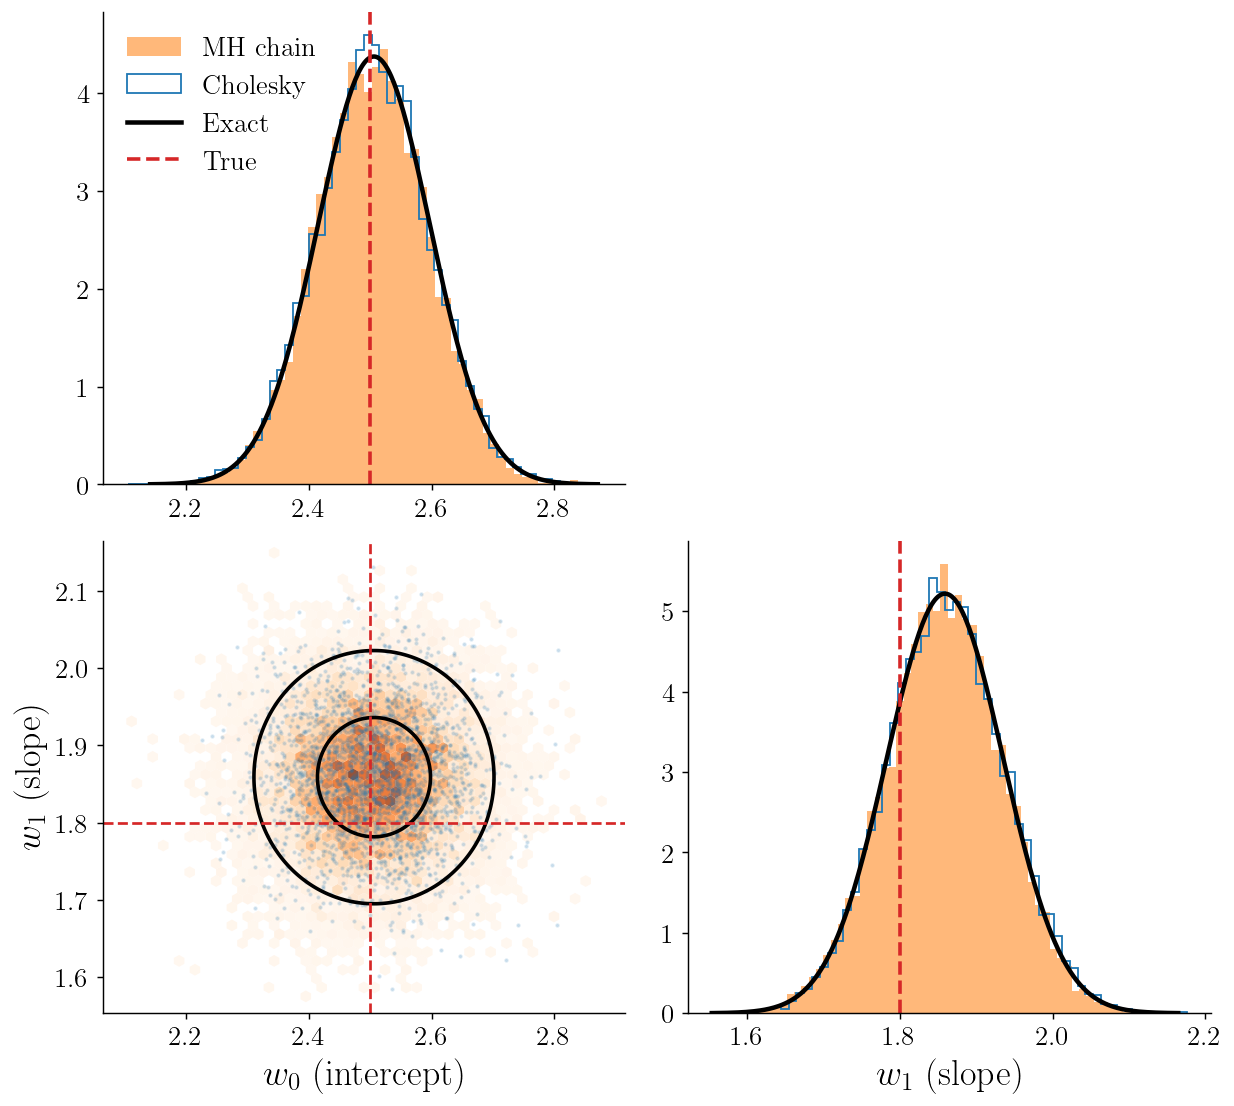

In [54]:
# ---------------------------------------------------------------------------
# Corner plot: exact posterior vs Cholesky samples vs MH chain
#
# The tilt of the joint contour encodes the classic slope-intercept
# anticorrelation: to pass a steeper line (large w1) through the same
# data cloud, the intercept (w0) must decrease.
#
# A correct sampler must reproduce:
#   1. The joint shape and orientation (black contours)
#   2. Both marginal curves (diagonal panels)
#   3. The posterior mean and covariance to within Monte Carlo noise
# Any discrepancy is a sampler bug, not a model feature.
# ---------------------------------------------------------------------------

# Exact 2D posterior on a grid for contour overlays
W0_G = np.linspace(m_N[0] - 4*np.sqrt(S_N[0,0]), m_N[0] + 4*np.sqrt(S_N[0,0]), 300)
W1_G = np.linspace(m_N[1] - 4*np.sqrt(S_N[1,1]), m_N[1] + 4*np.sqrt(S_N[1,1]), 300)
WW   = np.stack(np.meshgrid(W0_G, W1_G), axis=-1)
post_2d = mvn_dist(mean=m_N, cov=S_N).pdf(WW)

# Exact 1D marginals (the exact Gaussian marginal of each weight)
post_w0 = norm_dist(loc=m_N[0], scale=np.sqrt(S_N[0,0]))
post_w1 = norm_dist(loc=m_N[1], scale=np.sqrt(S_N[1,1]))

fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                          gridspec_kw={'hspace': 0.12, 'wspace': 0.12})

# ---- (0,0): marginal p(w0 | y) ----
ax = axes[0, 0]
ax.hist(w_mh[:,0], bins=60, density=True, color='tab:orange', alpha=0.55,
        label='MH chain')
ax.hist(w_gauss[:,0], bins=60, density=True, histtype='step',
        color='tab:blue', lw=2.0, label='Cholesky')
ax.plot(W0_G, post_w0.pdf(W0_G), color='k', lw=2.5, label='Exact')
ax.axvline(W_TRUE[0], color='tab:red', lw=2, ls='--', label='True')
ax.legend(fontsize=fontsi)
ax.tick_params(labelsize=fontsi)

# ---- (1,0): joint p(w0, w1 | y) ----
ax = axes[1, 0]
ax.hexbin(w_mh[:,0], w_mh[:,1], gridsize=45, cmap='Oranges',
          mincnt=1, linewidths=0, alpha=0.8)
ax.scatter(w_gauss[::4,0], w_gauss[::4,1], s=2, alpha=0.15,
           color='tab:blue', rasterized=True)
# Contour levels: fractions of max density giving ~68% and ~95% HPD regions
ax.contour(W0_G, W1_G, post_2d / post_2d.max(),
           levels=[np.exp(-2.30), np.exp(-0.51)],
           colors='k', linewidths=2.0)
ax.axvline(W_TRUE[0], color='tab:red', lw=1.5, ls='--')
ax.axhline(W_TRUE[1], color='tab:red', lw=1.5, ls='--')
ax.set_xlabel(r'$w_0$ (intercept)', fontsize=fontsi2)
ax.set_ylabel(r'$w_1$ (slope)',     fontsize=fontsi2)
ax.legend(fontsize=fontsi)
ax.tick_params(labelsize=fontsi)

# ---- (1,1): marginal p(w1 | y) ----
ax = axes[1, 1]
ax.hist(w_mh[:,1], bins=60, density=True, color='tab:orange', alpha=0.55)
ax.hist(w_gauss[:,1], bins=60, density=True, histtype='step',
        color='tab:blue', lw=2.0)
ax.plot(W1_G, post_w1.pdf(W1_G), color='k', lw=2.5)
ax.axvline(W_TRUE[1], color='tab:red', lw=2, ls='--')
ax.set_xlabel(r'$w_1$ (slope)', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)

axes[0, 1].axis('off')

plt.tight_layout()
plt.savefig('6_linreg_corner.pdf', bbox_inches='tight')
plt.show()
